In [1]:
import torch
import matplotlib.pyplot as plt
from src.tumor_detector import TumorDetector
from src.dataset import MRIDataset, load_subsets
from mpl_toolkits.axes_grid1 import make_axes_locatable

C:\Users\yuval\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_root = r"C:\Users\yuval\.cache\kagglehub\datasets\mateuszbuda\lgg-mri-segmentation\versions\2\kaggle_3m"
dataset = MRIDataset(dataset_root, limit=None)
_, _, test_dataset = load_subsets(dataset, test=True)

print(f"Successfully loaded {len(test_dataset)} test samples.")

Successfully loaded 392 test samples.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TumorDetector()
model.load_state_dict(torch.load(r"../../models/brain_tumor_model_v6/brain_tumor_model_v6.pth", map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


C:\Users\yuval\AppData\Local\Temp\ipykernel_18148\4027302966.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"models/brain_tumor_model_

In [4]:
captured_attn = []

def attention_hook(module, input, output):
    if isinstance(output, tuple) and len(output) > 1:
        captured_attn.append(output[1].detach().cpu())

def patched_forward(*args, **kwargs):
    kwargs['need_weights'] = True
    return orig_forward(*args, **kwargs)

target_module = model.transformer.transformer.layers[-1].self_attn
orig_forward = target_module.forward
target_module.forward = patched_forward
handle = target_module.register_forward_hook(attention_hook)

print("Hook is attached to the transformer")

Hook is attached to the transformer


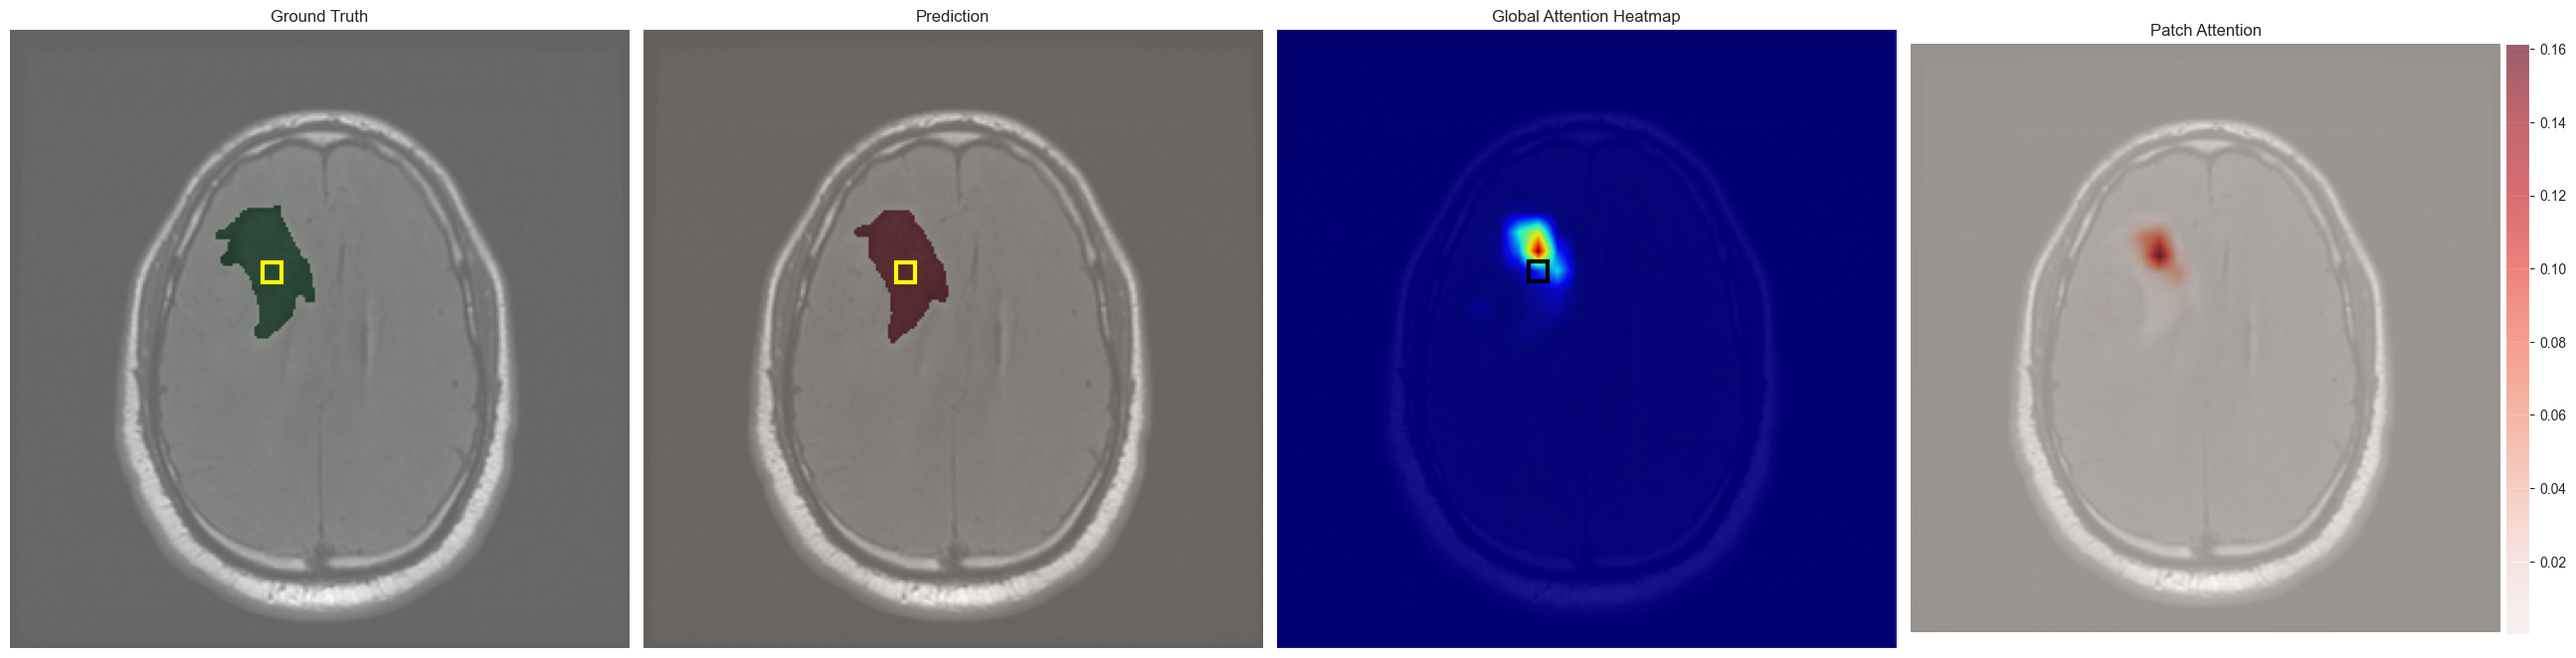

In [13]:
# recommended patches to look at: 292, 311, 218, 314, 315, 321
idx = 315
dx = 0
dy = 1

def focal_rect(x_focal, y_focal, patch_size, color='yellow'):
        return plt.Rectangle((x_focal * patch_size, y_focal * patch_size), patch_size, patch_size, linewidth=3, edgecolor=color, facecolor='none')

def visualize_attention(dx, dy, idx):
    image, mask = test_dataset[idx]
    img_input = image.unsqueeze(0).to(device)

    captured_attn.clear()
    with torch.no_grad():
        logits = model(img_input)
        pred_mask = torch.sigmoid(logits).squeeze().cpu().numpy()

    # attention processing
    if not captured_attn:
        return

    attn = captured_attn[0][0]                 # (1024, 1024)
    avg_attention_per_patch = attn.mean(dim=0) # (1024,)

    grid_size = 32
    patch_size = 8

    # setting focal patch
    focal_idx = torch.argmax(avg_attention_per_patch).item()
    y_focal, x_focal = divmod(focal_idx, grid_size)

    y_focal += dy
    x_focal += dx
    focal_idx = y_focal * grid_size + x_focal

    # attention (rows)
    row_map = (attn[focal_idx, :].detach().cpu().view(grid_size, grid_size).numpy())

    # global attention
    attn_map = (avg_attention_per_patch.detach().cpu().view(grid_size, grid_size).numpy())

    attn_map_norm = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

    # plot
    fig, ax = plt.subplots(1, 4, figsize=(26, 14))

    ax[0].imshow(image.squeeze(), cmap='gray')
    ax[0].imshow(mask.squeeze(), alpha=0.4, cmap='Greens')
    ax[0].add_patch(focal_rect(x_focal, y_focal, patch_size))
    ax[0].set_title("Ground Truth")

    ax[1].imshow(image.squeeze(), cmap='gray')
    ax[1].imshow(pred_mask > 0.7, alpha=0.4, cmap='Reds')
    ax[1].add_patch(focal_rect(x_focal, y_focal, patch_size))
    ax[1].set_title("Prediction")

    ax[2].imshow(image.squeeze(), cmap='gray')
    ax[2].imshow(attn_map_norm, cmap='jet', alpha=0.9, extent=(0, 256, 256, 0), interpolation='bilinear')
    ax[2].add_patch(focal_rect(x_focal, y_focal, patch_size, color='black'))
    ax[2].set_title("Global Attention Heatmap")

    ax[3].imshow(image.squeeze(), cmap='gray')
    im_row = ax[3].imshow(row_map, cmap='Reds', alpha=0.6, extent=(0, 256, 256, 0), interpolation='bilinear')
    ax[3].set_title("Patch Attention")
    divider2 = make_axes_locatable(ax[3])
    cax2 = divider2.append_axes("right", size="4%", pad=0.05)
    plt.colorbar(im_row, cax=cax2)

    for a in ax.flatten():
        a.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()

visualize_attention(dx, dy, idx)

In [6]:
tf_in = {}
tf_out = {}

def norm(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

def encoder_hook(module, inp, out):
    # out = (x1, x2, x3, x4)
    tf_in["x"] = out[-1].detach()  # x4 → transformer input

def transformer_hook(module, inp, out):
    tf_out["x"] = out.detach()

h1 = model.encoder.register_forward_hook(encoder_hook)
h2 = model.transformer.register_forward_hook(transformer_hook)

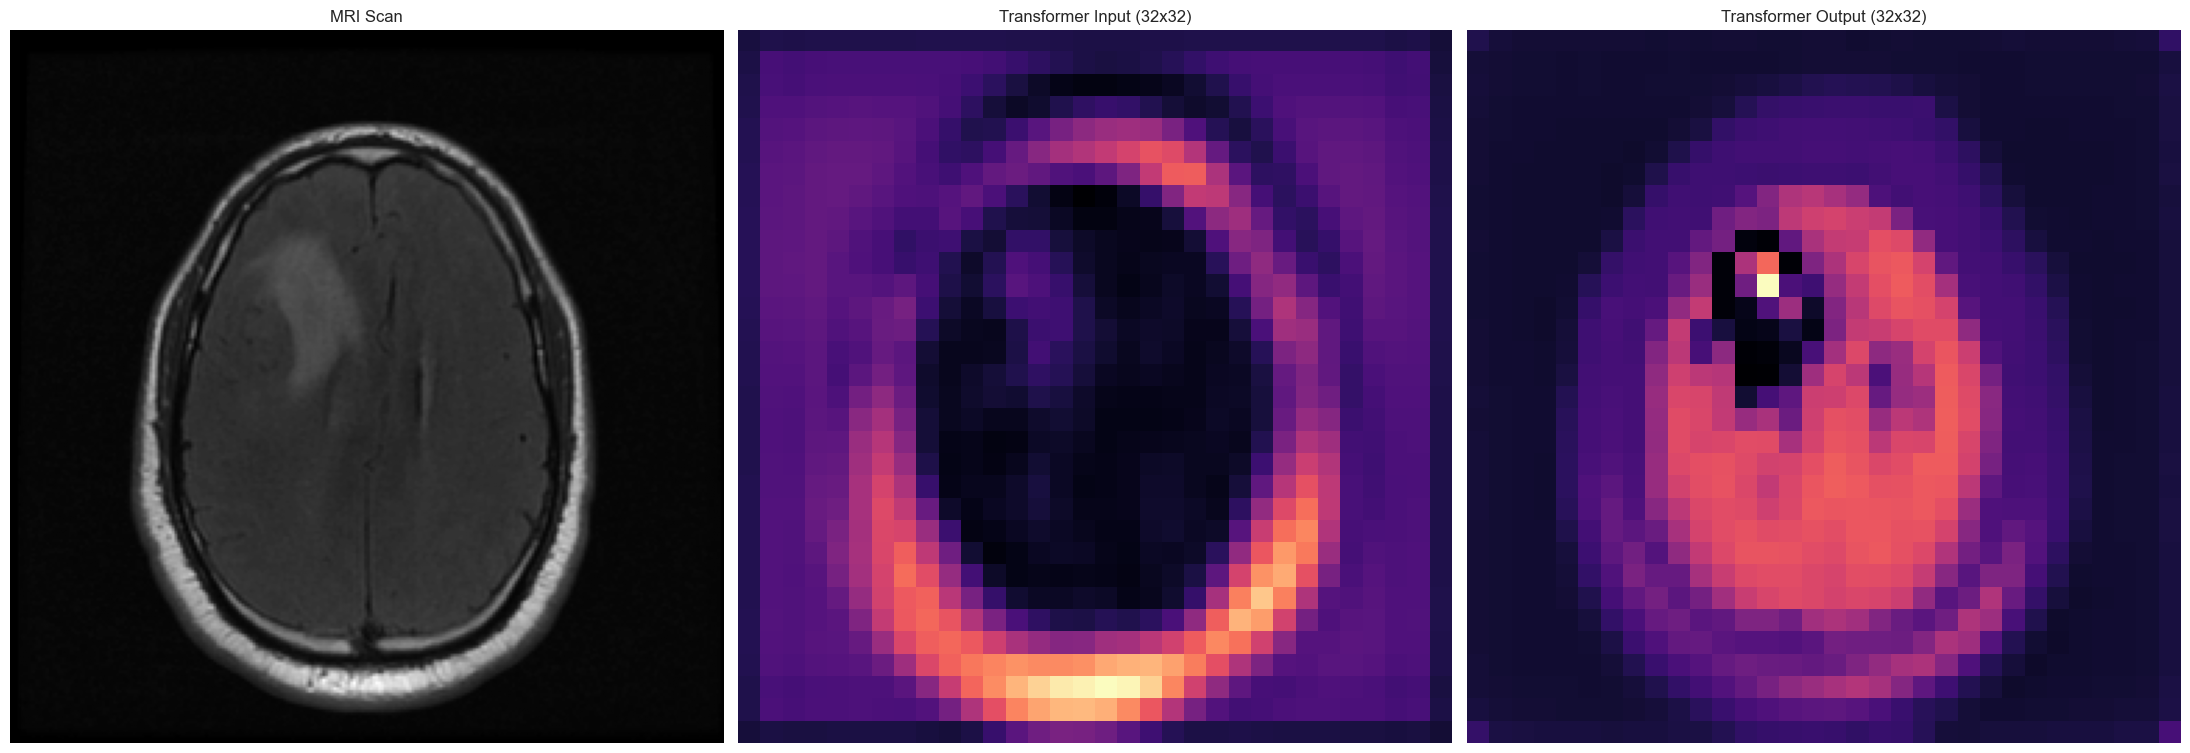

In [7]:
def visualize_transformer_io():
    image, mask = test_dataset[idx]
    img_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(img_input)

    h1.remove()
    h2.remove()

    enc = tf_in["x"][0]   # (512, 32, 32)
    tf  = tf_out["x"][0]  # (512, 32, 32)

    enc_map = torch.norm(enc, dim=0).cpu().numpy()
    tf_map  = torch.norm(tf,  dim=0).cpu().numpy()

    enc_map, tf_map = map(norm, [enc_map, tf_map])

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(22, 8))

    ax[0].imshow(image.squeeze(), cmap="gray")
    ax[0].set_title("MRI Scan")

    ax[1].imshow(enc_map, cmap="magma")
    ax[1].set_title("Transformer Input (32x32)")

    ax[2].imshow(tf_map, cmap="magma")
    ax[2].set_title("Transformer Output (32x32)")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

visualize_transformer_io()
